# SVM Classification — Alzheimer's Biomarker Data

Training a Support Vector Machine to classify cognitively normal (CN) vs. Alzheimer's disease (AD) cases from clinical and biological biomarker data, then running a systematic grid search across kernel type and regularization strength (C) to find which combination actually generalizes best, rather than guessing.

## 1. Load and preprocess the data

In [11]:
# Import all the libraries that you'll need in the session
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import pandas as pd

# load the AD dataset
df = pd.read_csv('AD-dataset.csv')
df.head()

,Unnamed: 0,RID,AGE,PTGENDER,WHOLECEREBELLUM_VOLUME,LEFT_HIPPOCAMPUS_SUVR,LEFT_HIPPOCAMPUS_VOLUME,RIGHT_HIPPOCAMPUS_SUVR,RIGHT_HIPPOCAMPUS_VOLUME,LEFT_AMYGDALA_SUVR,...,CTX_LH_ENTORHINAL_VOLUME,CTX_RH_BANKSSTS_SUVR,CTX_RH_BANKSSTS_VOLUME,CTX_RH_ENTORHINAL_SUVR,CTX_RH_ENTORHINAL_VOLUME,ABETA_bl,TAU_bl,PTAU_bl,DX_bl,DX_lon
0,1,23,71.7,Male,142109,1.286,4172,1.236,4236,1.180,...,1913,1.424,1749,0.909,1933,1647,181.1,16.74,CN,sCN
1,2,31,77.7,Female,103642,1.004,3605,1.097,3145,0.965,...,1244,1.375,1813,0.963,1398,>1700,266.8,22.55,CN,sCN
2,4,42,72.8,Male,122034,0.729,2323,0.751,1848,0.931,...,1052,1.108,1511,0.845,1480,1258,250.1,18.23,MCI,cMCI
3,5,47,84.7,Male,122574,0.906,3437,0.900,3069,0.933,...,2213,1.164,1824,0.815,1842,1410,224.4,21.4,CN,sCN
4,8,56,69.6,Female,116393,1.089,3808,1.079,3777,0.897,...,1887,1.105,1645,0.792,1652,1048,128.2,12.23,CN,cCN


In [12]:
### DATA PREPROCESSING ###
# Select columns
df = df.iloc[:, 2:]
df = df.drop (columns = ['DX_lon'])

# manipulate columns
df['PTGENDER'] = df['PTGENDER'].map({'Male': 0, 'Female': 1})
df['ABETA_bl'] = df['ABETA_bl'].replace({'>1700': 1700})
df['ABETA_bl'] = pd.to_numeric(df['ABETA_bl'], errors='coerce')
df['PTAU_bl'] = df['PTAU_bl'].replace({'<8': 8})
df['PTAU_bl'] = pd.to_numeric(df['PTAU_bl'], errors='coerce')
df.dropna(subset=['ABETA_bl'], inplace=True) # inplace=True to overwrite df

In [13]:
# drop the MCIs from the df (work only with two classes)
df_CN_AD = df[df['DX_bl'] != 'MCI']

# Get target names before dropping the column
target_names = df_CN_AD['DX_bl'].unique()

# feature data in X
X = df_CN_AD.drop('DX_bl', axis=1)
# label data in y. Use 0/1 mapping
y = df_CN_AD['DX_bl'].map({'CN': 0, 'AD': 1})

## 2. Implement an SVM


In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                  stratify=y, test_size=0.3, random_state=42)

# Define pipeline with StandardScaler + SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

# Define grid of hyperparameters.
param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__C': [0.01, 0.1, 1, 10, 100],
    'svc__gamma': ['scale'],        # Only used for 'rbf' and 'poly'
    'svc__degree': [2, 3]           # Only used for 'poly'
}

# Run GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid={'svc__C': [0.01, 0.1, 1, 10, 100],
                         'svc__degree': [2, 3], 'svc__gamma': ['scale'],
                         'svc__kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

## 3. Investigate which are the best hyperparameters

In [15]:
# Best results
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

# Evaluate on test set
y_pred = grid.predict(X_test)
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


# Convert results to DataFrame
results_df = pd.DataFrame(grid.cv_results_)

Best Parameters: {'svc__C': 0.1, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best Cross-Validation Accuracy: 0.9055370985603544

Test Set Classification Report:
              precision    recall  f1-score   support

          CN       0.92      0.86      0.89        56
          AD       0.79      0.89      0.84        35

    accuracy                           0.87        91
   macro avg       0.86      0.87      0.86        91
weighted avg       0.87      0.87      0.87        91



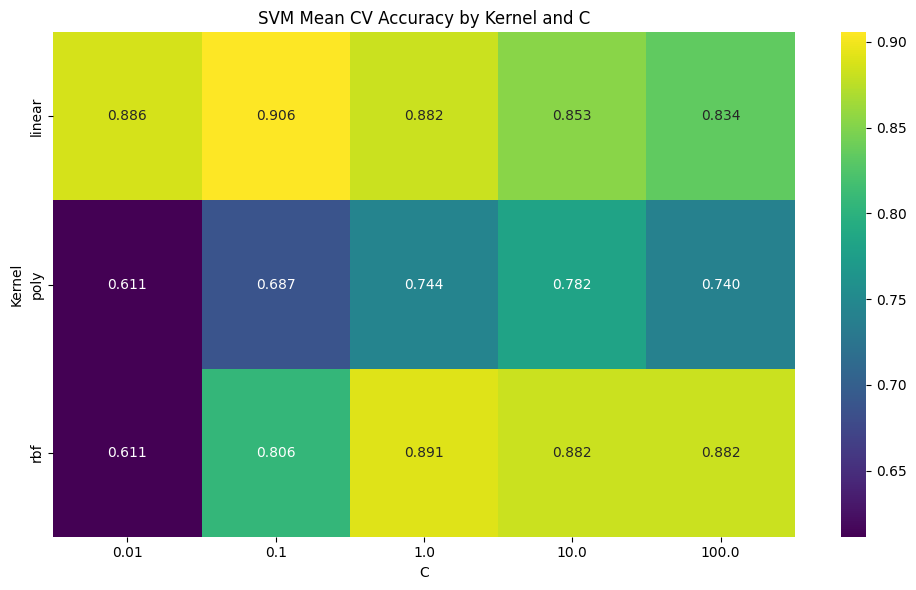

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
# Filter relevant columns
summary = results_df[['param_svc__kernel', 'param_svc__C', 'mean_test_score']]

# Group by kernel and C (averaging over degrees/gamma where repeated)
summary = summary.groupby(['param_svc__kernel', 'param_svc__C'],
                          as_index=False).mean()

# Pivot for heatmap
pivot_table = summary.pivot(index='param_svc__kernel',
                            columns='param_svc__C', values='mean_test_score')

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
plt.title("SVM Mean CV Accuracy by Kernel and C")
plt.xlabel("C")
plt.ylabel("Kernel")
plt.tight_layout()
plt.show()

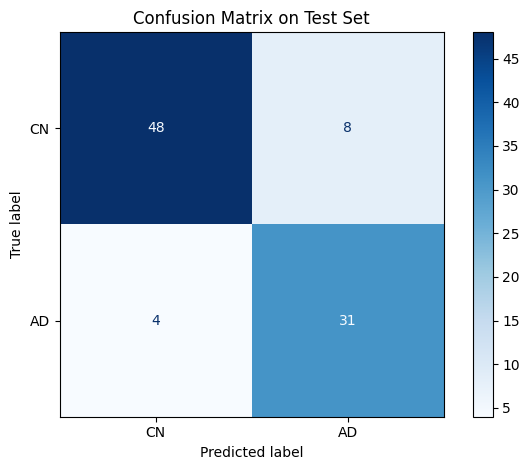

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()

### DISCUSSION

The linear kernel with C=0.1 appears to be the best choice among the tested hyperparameters for distinguishing between CN and AD in this dataset, providing a good balance of precision and recall for both classes on the test set. The model is slightly better at identifying AD cases (higher recall for AD) but with a trade-off in precision compared to the CN class.